# Classification

## 1. Dataset Loading and Audit

This section loads the Adult Income dataset and performs an initial audit of
the dataset, including its shape, data types, missing values, duplicates,
and target distribution.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
url = "https://raw.githubusercontent.com/snehitha-araveti/ML-Capstone-Project-2026/main/data/adult.csv"

df = pd.read_csv(url)

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (32561, 15)


### Data Types

In [5]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


### Missing Value Identification

In [6]:
df = df.replace("?", np.nan)

### Missing Value Summary

In [7]:
# Display missing-value count for each column
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


### Columns Containing Missing Values

In [8]:
print("Columns with Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Columns with Missing Values:
workclass         1836
occupation        1843
native.country     583
dtype: int64


### Target Class Distribution

In [9]:
# Target/Class Distribution
print("Target Distribution:")
print(df["income"].value_counts())

print("\nTarget Distribution (%):")
print(df["income"].value_counts(normalize=True) * 100)

Target Distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Target Distribution (%):
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


### Observation – Dataset Audit

The dataset contains a combination of numerical and categorical features, with `income` as the target variable. Missing values are present in some categorical features and are represented as `NaN` after replacing the original `?` markers. The target variable contains two income classes, with the `<=50K` class occurring more frequently than the `>50K` class.

## A2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distributions of the features, relationships among numerical variables, target-class balance, and potential relationships between selected features and the income class.

### Feature Identification

In [12]:
# Separate input features from target

target = "income"

numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

# Remove target from categorical features
categorical_features.remove(target)

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Categorical Features:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


### Numerical Feature Distributions

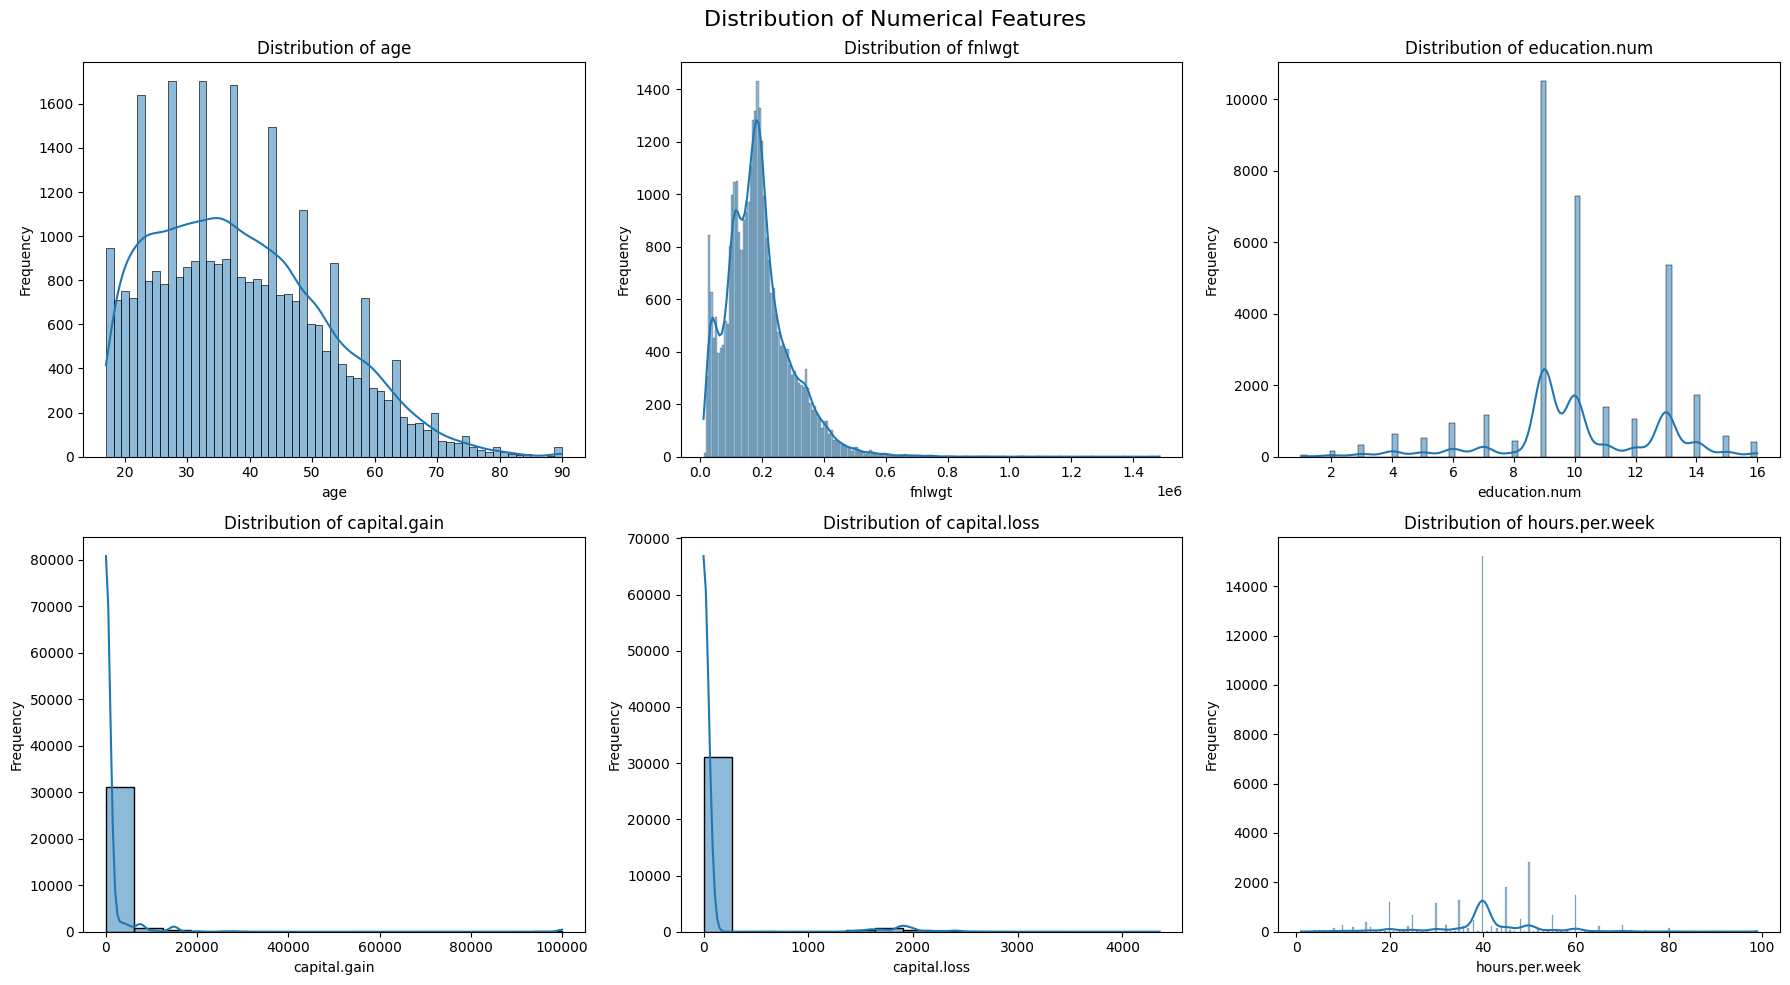

In [13]:
# Distribution plots for numerical features

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i])

    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observation – Numerical Feature Distributions

- **Age:** The distribution is concentrated mainly among working-age adults, with fewer observations at very young and very old ages.
- **fnlwgt:** The feature shows a wide and right-skewed distribution, indicating substantial variation in the sampling weights.
- **education.num:** The values are concentrated around the middle education levels, with fewer observations at the lowest and highest levels.
- **capital.gain:** Most observations have zero capital gain, while a small number of observations have substantially higher values, indicating strong right skewness.
- **capital.loss:** Similar to capital gain, most observations have zero capital loss, while relatively few observations have larger values.
- **hours.per.week:** Most observations are concentrated around the typical full-time working range, with fewer observations at very low or very high working hours.

### Categorical Feature Distributions

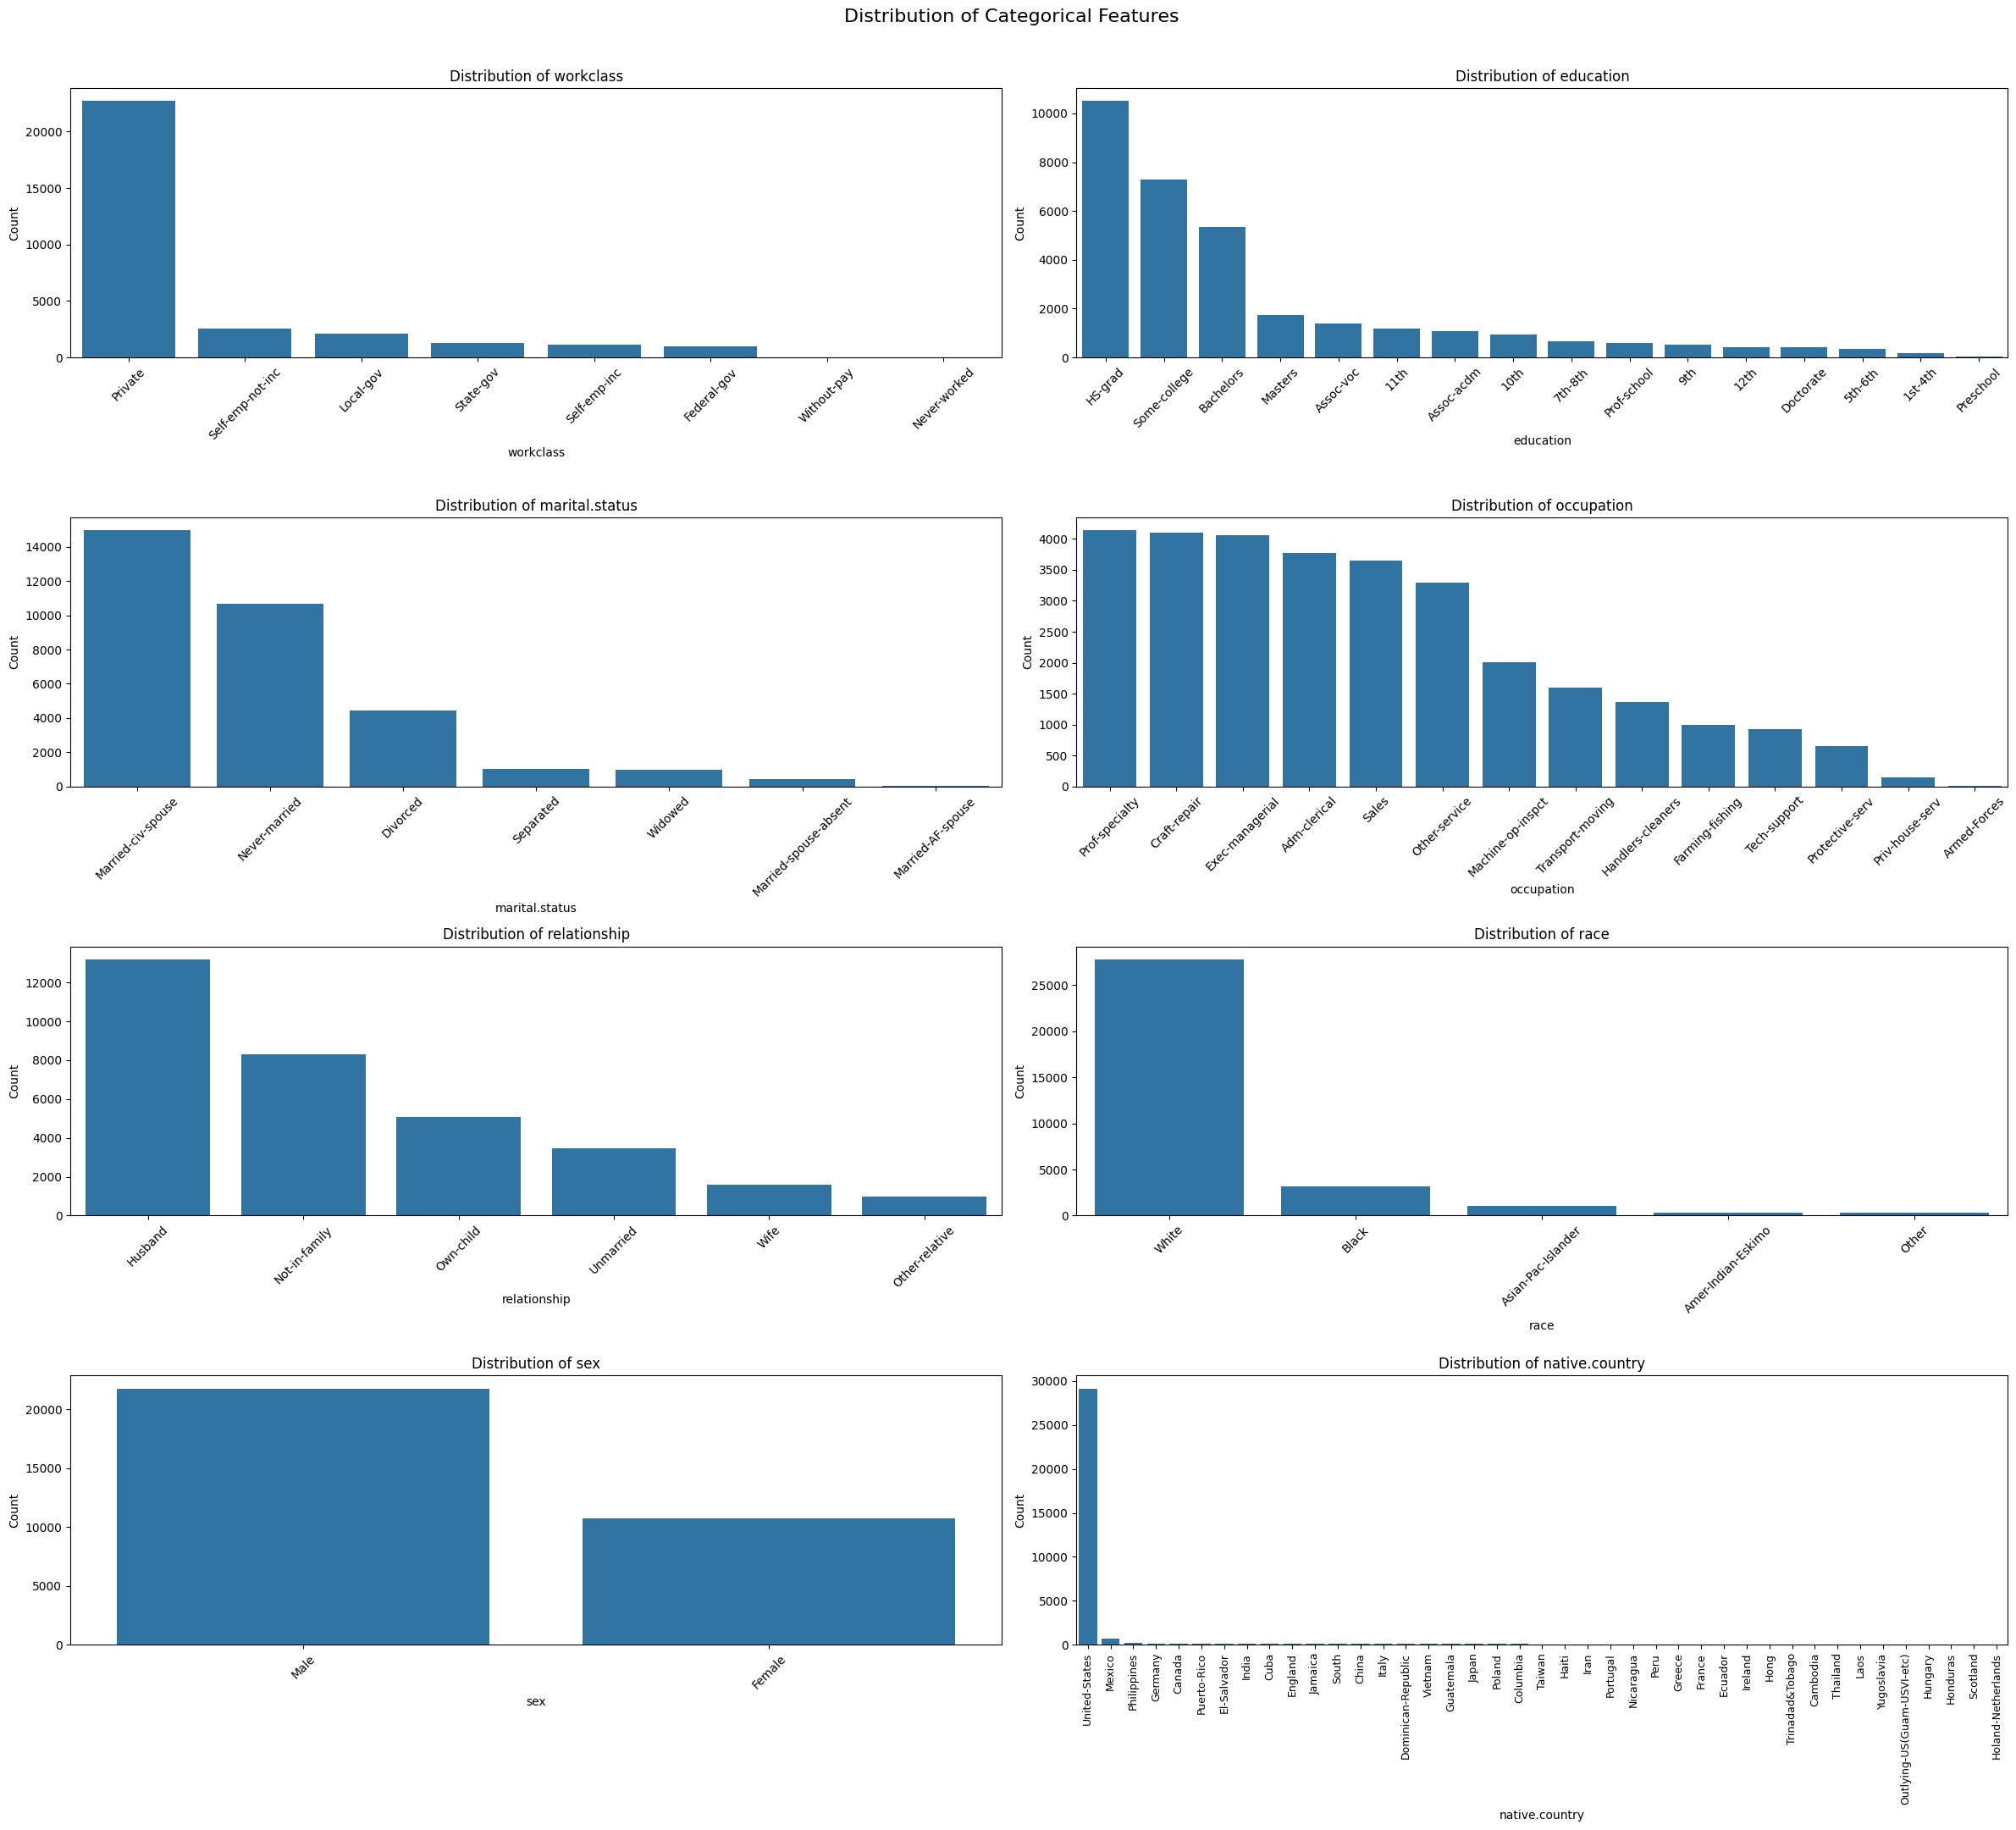

In [14]:
# Distribution plots for categorical features

fig, axes = plt.subplots(4, 2, figsize=(24, 22))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        x=feature,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

    # Rotate category labels
    if feature == "native.country":
        axes[i].tick_params(axis="x", rotation=90, labelsize=9)
    else:
        axes[i].tick_params(axis="x", rotation=45)

plt.suptitle(
    "Distribution of Categorical Features",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### Observation – Categorical Feature Distributions

- **Workclass:** The dataset is dominated by the Private workclass, while several other workclass categories contain considerably fewer observations.
- **Education:** A few education categories account for a large proportion of the observations, while higher-level categories are less frequent.
- **Marital Status:** Married-civil-spouse is the most frequent category, followed by several unmarried or previously married categories.
- **Occupation:** Some occupations are substantially more common than others, showing an uneven distribution across occupational groups.
- **Relationship:** Husband and Not-in-family represent prominent groups, while some relationship categories have relatively few observations.
- **Race:** The White category forms the majority of observations, with the remaining racial categories representing smaller groups.
- **Sex:** The dataset contains more observations for Male than Female.
- **Native Country:** United-States is overwhelmingly the most frequent category, while many other countries have relatively small numbers of observations.

### Correlation Heatmap

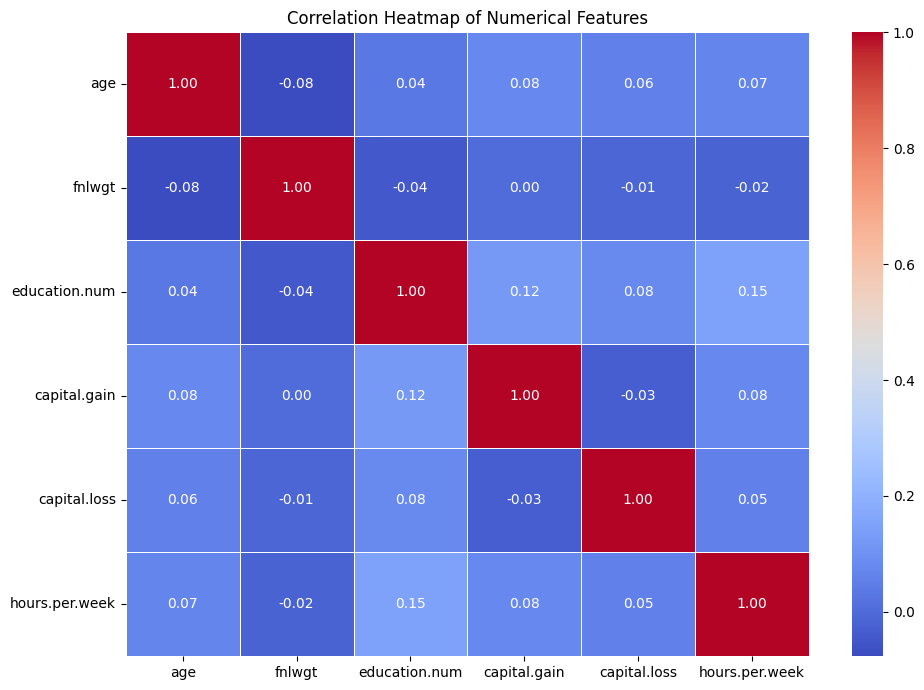

In [15]:
# Correlation heatmap for numerical features

plt.figure(figsize=(10, 7))

correlation_matrix = df[numerical_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


### Observation – Correlation Heatmap

The correlation heatmap shows the strength and direction of linear relationships among the numerical features. Most feature pairs exhibit weak correlations, while some variables show comparatively stronger relationships. The heatmap also indicates that the numerical features do not all provide redundant information, suggesting that multiple features may contribute different information to the classification task.

### Target Distribution

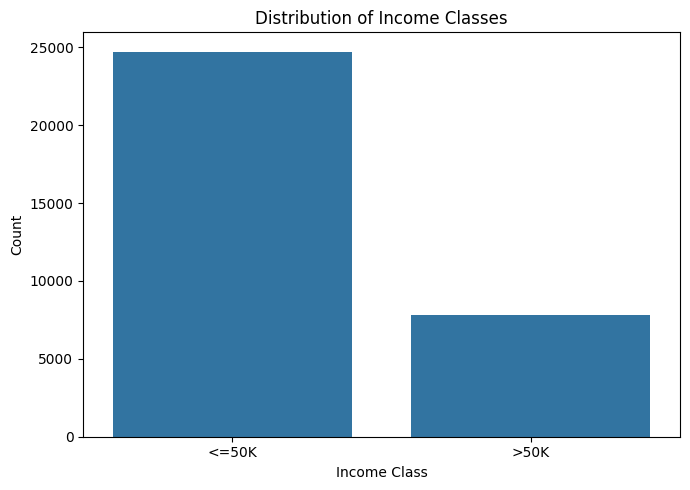

In [16]:
# Target distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="income",
    order=df["income"].value_counts().index
)

plt.title("Distribution of Income Classes")
plt.xlabel("Income Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation – Income Class Distribution

The target variable is not evenly distributed across the two income classes. The `<=50K` class contains substantially more observations than the `>50K` class, indicating class imbalance in the dataset. Therefore, model evaluation should consider metrics such as precision, recall, weighted F1-score, and the confusion matrix rather than relying only on accuracy.

### Income Class Representation for Visualization

In [17]:
# Create numerical representation of income for visualization

income_numeric = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

### Age vs Income Class

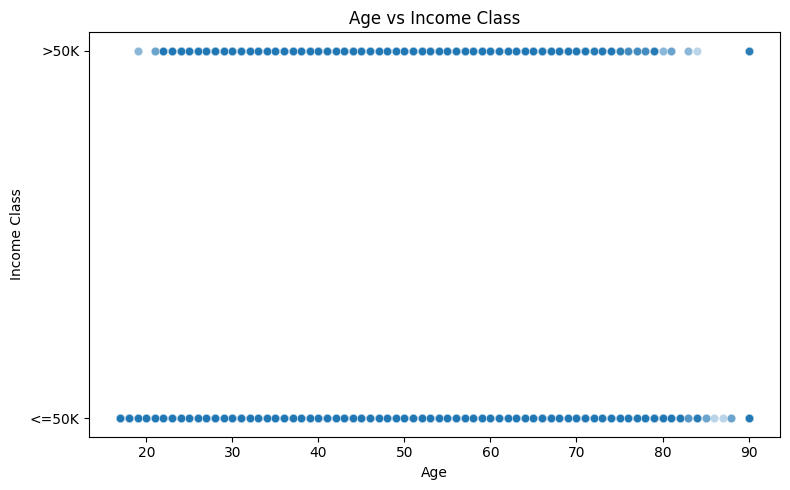

In [18]:
# Scatter plot: Age vs Income

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["age"],
    y=income_numeric,
    alpha=0.3
)

plt.title("Age vs Income Class")
plt.xlabel("Age")
plt.ylabel("Income Class")
plt.yticks([0, 1], ["<=50K", ">50K"])

plt.tight_layout()
plt.show()

### Observation – Age vs Income

The scatter plot shows that both income classes occur across a wide range of ages. However, the distribution of observations suggests that the higher-income class becomes more prominent among older working-age individuals. This indicates that age may provide useful information for distinguishing between the two income classes.

### Hours per Week vs Income Class

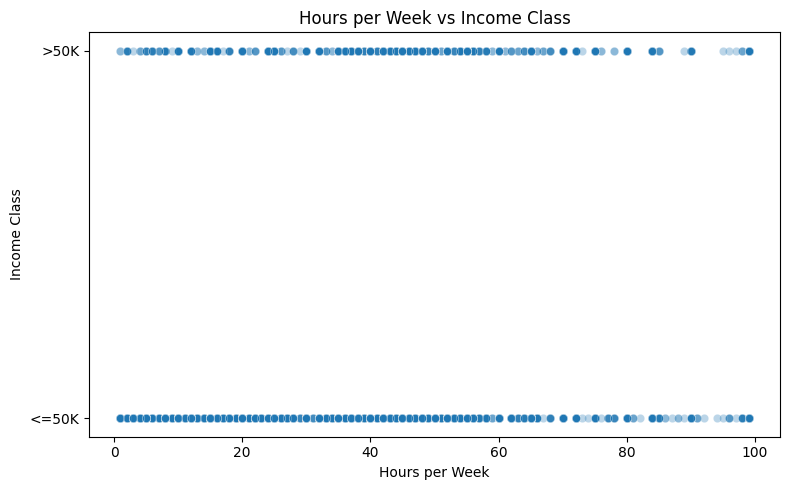

In [19]:
# Scatter plot: Hours per Week vs Income

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["hours.per.week"],
    y=income_numeric,
    alpha=0.3
)

plt.title("Hours per Week vs Income Class")
plt.xlabel("Hours per Week")
plt.ylabel("Income Class")
plt.yticks([0, 1], ["<=50K", ">50K"])

plt.tight_layout()
plt.show()

### Observation – Hours per Week vs Income

The scatter plot shows that both income classes occur across different working-hour levels. The higher-income class appears more frequently at higher working hours, although there is considerable overlap between the two classes. This suggests that hours worked per week may provide useful predictive information, but it is unlikely to be sufficient on its own for accurate classification.

## A3. EDA Insights

The exploratory analysis shows that the Adult dataset contains both numerical and categorical features with varied distributions. Several numerical features are skewed, particularly `capital.gain` and `capital.loss`, while categorical variables show uneven category frequencies. The target variable is imbalanced, with more observations belonging to the `<=50K` class. The visualizations of age and hours worked per week also indicate that these features may provide useful information for distinguishing between income classes, although there is considerable overlap between the two groups.